# Aula 7 - Inferência Estatística

## Motivação

Na Aula 5, a estatística descritiva resumiu os dados observados sem
generalizá-los. Na Aula 6, o diagnóstico orientou o tratamento da base.
Em ambas, as conclusões ficaram restritas à amostra disponível. Nesta
aula, damos o passo seguinte. Ao comparar dois grupos, encontramos uma
diferença. A pergunta passa a ser se essa diferença diz algo sobre o
processo que gerou os dados ou se é apenas um resultado da variabilidade
aleatória da amostra.

Considere um exemplo clássico. A revista *Motor Trend* mediu, em 1974, o
consumo de 32 modelos de carro. Os carros com câmbio manual percorrem,
em média, cerca de 7 milhas a mais por galão do que os automáticos. A
diferença parece grande, mas a amostra é pequena. Se a revista tivesse
escolhido outros 32 carros, a diferença seria outra. Talvez menor,
talvez nula, talvez invertida.

A estatística inferencial oferece um procedimento para responder a essa
pergunta. Primeiro, supomos que **não existe** efeito algum. Em seguida,
medimos quão raro seria observar uma diferença do tamanho da encontrada
se essa suposição fosse verdadeira. Se a diferença for muito rara sob o
acaso, temos evidência contra a suposição inicial. Estudaremos duas
formas de construir essa referência: uma por simulação, o **teste de
permutação**, e outra por fórmula, o **teste *t* de Student**.

> **Diferença real ou acaso?**

## Objetivos de aprendizagem

Ao final deste roteiro, você será capaz de:

1.  Medir o efeito observado ($\Delta_{obs}$) entre dois grupos e
    comparar sua dispersão com boxplots.
2.  Formular a hipótese nula ($H_0$) e a hipótese alternativa ($H_1$)
    para uma comparação entre grupos.
3.  Aplicar o teste de permutação e construir a distribuição empírica do
    acaso.
4.  Aplicar o teste *t* de Student, reconhecendo suas premissas, seus
    limites e sua sensibilidade a valores atípicos.
5.  Interpretar o *p*-valor, o nível de significância ($\alpha$) e os
    erros dos tipos I e II, distinguindo significância estatística de
    relevância prática.

> **Como usar este roteiro**
>
> O roteiro usa a base `mtcars.csv`, salva em `mtcars/data/`, e um
> conjunto simulado de atendimentos em um pronto-socorro, gerado no
> próprio roteiro.
>
> Não é necessário instalar novas bibliotecas. Os testes usam o módulo
> `stats` do SciPy, já empregado nas aulas anteriores.
>
> Ao final, três perguntas ajudam a consolidar a interpretação dos
> testes.

# 1. Preparando os dados

Começamos importando as bibliotecas usadas na simulação, nos testes e na
visualização.

In [1]:
# Importa as bibliotecas e define o tema dos gráficos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="colorblind")

A base `mtcars` reúne 32 modelos de carro vendidos nos Estados Unidos em
1973 e 1974. Usaremos duas de suas onze colunas:

| Coluna | Significado                                                |
|--------|------------------------------------------------------------|
| `mpg`  | Consumo, em milhas por galão. Quanto maior, mais econômico |
| `am`   | Câmbio: 0 = automático, 1 = manual                         |

Ao carregar a base, criamos uma coluna auxiliar com um rótulo legível
para o câmbio.

In [2]:
# Carrega a base e cria o rótulo do câmbio
mtcars = (
    pd.read_csv("mtcars/data/mtcars.csv")
    .assign(
        transmission=lambda df: np.where(
            df["am"] == 1,
            "Manual",
            "Automático",
        ),
    )
)

mtcars.head()

# 2. A diferença observada

O primeiro passo de qualquer comparação é descritivo. Calculamos uma
estatística em cada grupo e medimos a distância entre elas. Chamamos
essa distância de **efeito observado**:

$$
\Delta_{obs} = \bar{x}_A - \bar{x}_B
$$

Aqui, $\bar{x}_A$ e $\bar{x}_B$ são as médias amostrais dos grupos A e
B. O sinal indica o sentido da diferença. Neste roteiro, o grupo A é
sempre aquele em que suspeitamos de um efeito: os carros manuais e, mais
adiante, os dias de lua cheia. Quando há assimetria ou valores atípicos,
a diferença de medianas é uma alternativa mais robusta, pelos mesmos
motivos discutidos na Aula 5.

Antes de calcular a diferença, resumimos cada grupo:

In [3]:
# Tamanho, média, mediana e desvio-padrão do consumo por câmbio
(
    mtcars
    .groupby("transmission")
    .mpg
    .agg(["size", "mean", "median", "std"])
    .round(2)
)

A tabela traz três informações importantes:

-   **Os grupos têm tamanhos diferentes.** São 19 automáticos e 13
    manuais. Nenhum dos dois é grande, e cada carro tem peso
    considerável na média do seu grupo.
-   **Média e mediana contam histórias um pouco diferentes.** Nos
    automáticos, as duas quase coincidem (17,15 e 17,3). Nos manuais, a
    média (24,39) fica acima da mediana (22,8), sinal de que alguns
    carros muito econômicos puxam a média para cima.
-   **Os manuais variam mais.** O desvio-padrão dos manuais (6,17) é
    cerca de 60% maior que o dos automáticos (3,83).

A diferença de médias resume a comparação em um único número:

In [4]:
# Efeito observado: diferença das médias de consumo
manual = mtcars.loc[mtcars.am == 1, "mpg"]
automatic = mtcars.loc[mtcars.am == 0, "mpg"]

delta_obs = manual.mean() - automatic.mean()

round(delta_obs, 2)

np.float64(7.24)

Os carros manuais fazem, em média, 7,24 milhas por galão a mais. A
diferença de medianas é menor, 5,5 mpg, coerente com a assimetria
observada nos manuais. Nas duas medidas, porém, os manuais aparecem como
mais econômicos.

O boxplot mostra a diferença e a dispersão de cada grupo. Cada ponto é
um carro, e as linhas tracejadas marcam as médias. Como faremos o mesmo
gráfico para o pronto-socorro, o boxplot com as observações sobrepostas
fica em uma função:

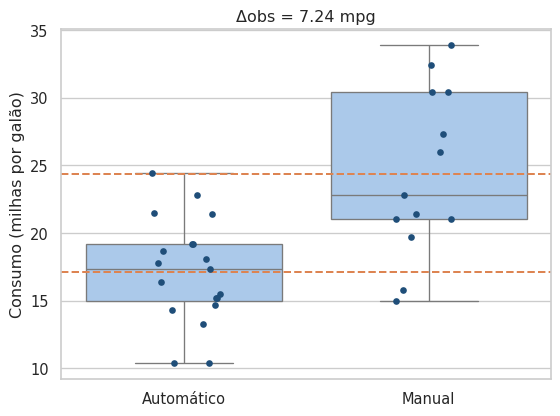

In [5]:
# Boxplot com as observações sobrepostas e as médias de cada grupo
def plot_groups(data, x, y, order, ax, alpha=1, jitter=.15):
    sns.boxplot(
        data=data, x=x, y=y, order=order, ax=ax,
        color="#A1C9F4",
        showfliers=False,
    )
    sns.stripplot(
        data=data, x=x, y=y, order=order, ax=ax,
        color="#1F4E79", alpha=alpha, jitter=jitter,
    )

fig, ax = plt.subplots(figsize=(6, 4.5))
plot_groups(mtcars, "transmission", "mpg", ["Automático", "Manual"], ax)
for mean in [automatic.mean(), manual.mean()]:
    ax.axhline(mean, color="#DD8452", linestyle="--")
ax.set(title=f"Δobs = {delta_obs:.2f} mpg", xlabel="",
       ylabel="Consumo (milhas por galão)")
plt.tight_layout()
plt.show()

As caixas quase não se sobrepõem. A caixa dos manuais começa perto de
onde termina a dos automáticos, e a média dos manuais fica acima de
praticamente todos os automáticos. Ainda assim, há sobreposição nos
extremos: alguns automáticos consomem tão pouco quanto manuais típicos,
e alguns manuais consomem tanto quanto automáticos típicos.

Os manuais parecem mais econômicos. Mas $\Delta_{obs} \neq 0$ é apenas
uma descrição da amostra, não uma prova de diferença na população. Há
três motivos para cautela:

-   **Natureza estocástica.** Cada amostra é uma entre muitas
    realizações possíveis. A média amostral flutua em torno do parâmetro
    verdadeiro e, por isso, dois grupos sem diferença real raramente
    apresentam médias idênticas.
-   **Sensibilidade a valores atípicos.** Um único valor extremo pode
    deslocar $\bar{x}$ e fabricar um $\Delta_{obs}$ expressivo que não
    representa a maior parte dos dados.
-   **Recorte limitado.** Os dados capturam uma janela no tempo e no
    espaço. Viés de amostragem e fatores ocultos limitam a extrapolação.

O primeiro motivo é o tema central desta aula. Antes de formalizá-lo,
vejamos como ele engana a intuição.

# 3. O problema da aleatoriedade

A **apofenia** é a tendência humana de perceber padrões e relações
significativas em dados puramente aleatórios. Vemos rostos em nuvens e
sequências em números sorteados. Uma variante conhecida é a *falácia do
atirador do Texas*: atirar contra a parede de um celeiro e, só depois,
desenhar o alvo em volta do grupo de tiros mais próximos.

Um exemplo clássico entre profissionais de saúde é a crença de que
“plantão de lua cheia é sempre cheio”. Uma meta-análise com dezenas de
estudos (Rotton & Kelly, 1985) não encontrou relação entre as fases da
lua e o comportamento humano. A crença persiste por viés de confirmação:
a noite agitada de lua cheia vira história, e a noite calma é esquecida.

## 3.1 Um pronto-socorro simulado

Para estudar a crença, simulamos um ano de atendimentos em um
pronto-socorro fictício. A simulação tem uma vantagem didática
importante: **sabemos** que a lua não tem efeito, porque os atendimentos
de todos os dias são sorteados da mesma distribuição. Qualquer diferença
que encontrarmos entre os grupos terá sido produzida apenas pelo acaso.

In [6]:
# Um ano de atendimentos diários, sem nenhum efeito da lua
rng = np.random.default_rng(2726)

full_moon_days = np.round(np.arange(12) * 29.53 + 14)

er_visits = (
    pd.DataFrame({"day": np.arange(365)})
    .assign(
        visits=rng.poisson(120, size=365),
        full_moon=lambda df: df["day"].isin(full_moon_days),
        moon=lambda df: np.where(df["full_moon"], "Lua cheia", "Demais dias"),
    )
)

Resumimos os dois grupos da mesma forma que no `mtcars`:

In [7]:
# Atendimentos por dia em cada grupo
(
    er_visits
    .groupby("moon")
    .visits
    .agg(["size", "mean", "median", "std"])
    .round(2)
)

Os dias de lua cheia tiveram média de 123,67 atendimentos, contra 119,78
nos demais dias. A mediana também é maior na lua cheia (121,5 contra
119). Os dois grupos têm desvio-padrão parecido, entre 9 e 11
atendimentos.

Esse desvio-padrão ajuda a entender o que está acontecendo. Em uma
distribuição de Poisson, a variância é igual à média. Com média de 120
atendimentos, o desvio-padrão diário é de cerca de
$\sqrt{120} \approx 11$. Um dia comum pode facilmente ter 110 ou 130
atendimentos. A média de apenas 12 dias ainda carrega boa parte dessa
oscilação, enquanto a média de 353 dias é muito mais estável. Quando
comparamos as duas médias, a oscilação do grupo pequeno aparece como uma
“diferença”.

Assim como fizemos com `manual` e `automatic`, separamos os atendimentos
de cada grupo e calculamos o efeito observado:

In [8]:
# Atendimentos de cada grupo e efeito observado da lua cheia
moon_in = er_visits.loc[er_visits.full_moon, "visits"]
moon_out = er_visits.loc[~er_visits.full_moon, "visits"]

moon_obs = moon_in.mean() - moon_out.mean()

round(moon_obs, 2)

np.float64(3.88)

O boxplot usa a mesma função `plot_groups`. Com 365 pontos, aumentamos a
transparência para que a sobreposição não esconda a distribuição.

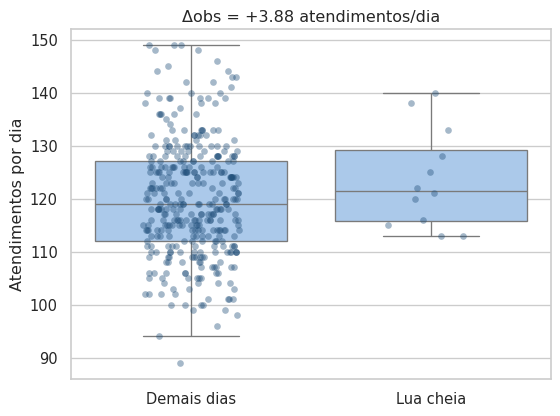

In [9]:
# Atendimentos por grupo
fig, ax = plt.subplots(figsize=(6, 4.5))

plot_groups(
    er_visits, "moon", "visits", ["Demais dias", "Lua cheia"], ax,
    alpha=.4, jitter=.2,
)

ax.set(
    title=f"Δobs = {moon_obs:+.2f} atendimentos/dia",
    xlabel="",
    ylabel="Atendimentos por dia",
)

plt.tight_layout()
plt.show()

Os dias de lua cheia tiveram, em média, cerca de 3,9 atendimentos a
mais. O resultado parece confirmar a crença, embora tenhamos construído
os dados **sem** qualquer efeito da lua. Compare este boxplot com o do
`mtcars`. Aqui, as caixas se sobrepõem quase inteiramente, e os 12
pontos da lua cheia se espalham pela mesma faixa ocupada pelos demais
dias.

Temos agora duas diferenças: 7,24 mpg no `mtcars` e 3,9 atendimentos no
pronto-socorro. Sabemos que a segunda é puro acaso. Precisamos de um
procedimento que, sem conhecer a resposta de antemão, distinga um caso
do outro. Esse procedimento precisa levar em conta não apenas o tamanho
da diferença, mas também quanto a diferença oscilaria se não houvesse
efeito algum.

# 4. Formalizando o acaso

## 4.1 Hipóteses nula e alternativa

Um teste de hipóteses confronta duas proposições sobre a **população**,
não sobre a amostra:

| Hipótese | Notação | Leitura |
|------------------------|------------------------|------------------------|
| Nula ($H_0$) | $\mu_A = \mu_B \iff \Delta = 0$ | Não há efeito. A diferença observada é fruto do acaso |
| Alternativa ($H_1$) | $\mu_A \neq \mu_B \iff \Delta \neq 0$ | Existe um efeito real no processo gerador dos dados |

Aqui, $\mu$ é a média populacional, $\Delta$ é o efeito verdadeiro, que
desconhecemos, e $\Delta_{obs}$ é sua estimativa na amostra. A hipótese
alternativa também aparece escrita como $H_a$.

Por que partir da hipótese de **ausência** de efeito? Porque é a única
das duas que descreve um cenário preciso. A hipótese “$\Delta = 0$” diz
exatamente como os dados deveriam se comportar, e isso nos permite
simular ou calcular o que esperar sob ela. A hipótese “$\Delta \neq 0$”
admite infinitos valores para o efeito e não fornece, sozinha, uma
referência para comparação.

Para os dois exemplos da aula:

| Exemplo | $H_0$ | $H_1$ |
|------------------------|------------------------|------------------------|
| Lua cheia | $\mu_{\text{lua cheia}} = \mu_{\text{demais dias}}$: a lua não afeta o movimento | $\mu_{\text{lua cheia}} \neq \mu_{\text{demais dias}}$: o movimento muda em noites de lua cheia |
| `mtcars` | $\mu_{\text{manual}} = \mu_{\text{automático}}$: o câmbio não afeta o consumo | $\mu_{\text{manual}} \neq \mu_{\text{automático}}$: o consumo difere entre os câmbios |

As hipóteses alternativas acima são **bilaterais**: admitem diferenças
nos dois sentidos. Uma alternativa **unilateral**, como
“$\mu_{\text{lua cheia}} > \mu_{\text{demais dias}}$”, só consideraria o
aumento de atendimentos. Usamos a versão bilateral porque, antes de
olhar os dados, uma diferença no sentido oposto também seria
informativa. Escolher o sentido depois de ver qual grupo teve a maior
média seria uma forma de desenhar o alvo depois dos tiros.

A lógica do teste lembra a de um tribunal:

| Julgamento                           | Teste de hipóteses                 |
|------------------------------------|------------------------------------|
| Presunção de inocência               | $H_0$: não há efeito               |
| Provas apresentadas                  | Dados observados ($\Delta_{obs}$)  |
| Culpado “além de dúvida razoável”    | *p*-valor $\leq \alpha$            |
| Condenar um inocente                 | Erro do tipo I (falso positivo)    |
| Absolver um culpado                  | Erro do tipo II (falso negativo)   |
| “Não culpado” não significa inocente | Não rejeitar $H_0$ não prova $H_0$ |

O réu é considerado inocente até que as provas tornem essa hipótese
difícil de sustentar. Da mesma forma, partimos de $H_0$ e só a
abandonamos se os dados forem improváveis sob ela. A última linha da
tabela merece atenção. Um réu absolvido por falta de provas não foi
declarado inocente. Da mesma forma, não rejeitar $H_0$ significa apenas
que os dados não trouxeram evidência suficiente contra ela.

## 4.2 O teste de permutação

Se $H_0$ for verdadeira, o rótulo “lua cheia” não carrega informação
alguma sobre o número de atendimentos. Os 365 valores vêm de uma única
distribuição, e o rótulo poderia estar em quaisquer 12 dias do ano.
Dizemos que, sob $H_0$, os rótulos são **intercambiáveis**.

Essa ideia leva a um procedimento em quatro passos:

1.  **Medir.** Calcular a estatística nos dados reais: $\Delta_{obs}$.
2.  **Embaralhar.** Sob $H_0$, os rótulos não importam. Sortear
    novamente quais observações recebem cada rótulo.
3.  **Recalcular.** Calcular a mesma estatística nos dados embaralhados:
    $\Delta_{perm}$.
4.  **Repetir.** Fazer isso muitas vezes, por exemplo 10.000, para obter
    a distribuição empírica de $\Delta$ sob o acaso, chamada
    **distribuição nula**.

Um exemplo pequeno ajuda a fixar o procedimento. Suponha seis
observações, três do grupo A e três do grupo B:

| Valor             | 12  | 15  | 18  | 9   | 10  | 14  | Média A | Média B | $\Delta$  |
|-------------------|-----|-----|-----|-----|-----|-----|---------|---------|-----------|
| Rótulos reais     | A   | A   | A   | B   | B   | B   | 15,00   | 11,00   | $+4{,}00$ |
| Um embaralhamento | A   | B   | B   | A   | B   | A   | 11,67   | 14,33   | $-2{,}67$ |

Os valores permanecem nas mesmas posições. Apenas os rótulos trocam de
lugar, sempre com três A e três B. Com seis observações, há apenas 20
maneiras de escolher quais três recebem o rótulo A, e poderíamos listar
todas. No pronto-socorro, há cerca de $9{,}7 \times 10^{21}$ maneiras de
escolher 12 dias entre 365. Por isso, em vez de listar todas, sorteamos
uma amostra grande delas.

Como aplicaremos o procedimento aos dois exemplos da aula, ele fica em
uma função. A cada repetição, a função embaralha os rótulos e recalcula
a diferença de médias. Em seguida, aplicamos a função aos dados do
pronto-socorro:

In [10]:
# Distribuição nula por permutação, aplicada à lua cheia
def permutation_null(values, labels, n_perm=10_000, seed=2026):
    rng = np.random.default_rng(seed)
    null = []
    for _ in range(n_perm):
        shuffled = rng.permutation(labels)
        null.append(values[shuffled].mean() - values[~shuffled].mean())
    return np.array(null)

moon_values = er_visits["visits"].to_numpy()
moon_labels = er_visits["full_moon"].to_numpy()

moon_null = permutation_null(moon_values, moon_labels)

moon_null[:5].round(2)

array([-5.33, -6.46, -2.23, -1.54,  4.49])

Os cinco primeiros valores mostram o que o acaso produz. Alguns sorteios
deram diferenças positivas, outros negativas, e algumas delas são
maiores, em módulo, que os 3,9 atendimentos observados. Cada valor de
`moon_null` é a diferença que teríamos observado se 12 dias quaisquer
tivessem recebido o rótulo de lua cheia.

O histograma reúne as 10.000 diferenças. Como $H_1$ é bilateral,
marcamos $+\Delta_{obs}$ e $-\Delta_{obs}$. Como faremos o mesmo gráfico
para o `mtcars`, ele também fica em uma função:

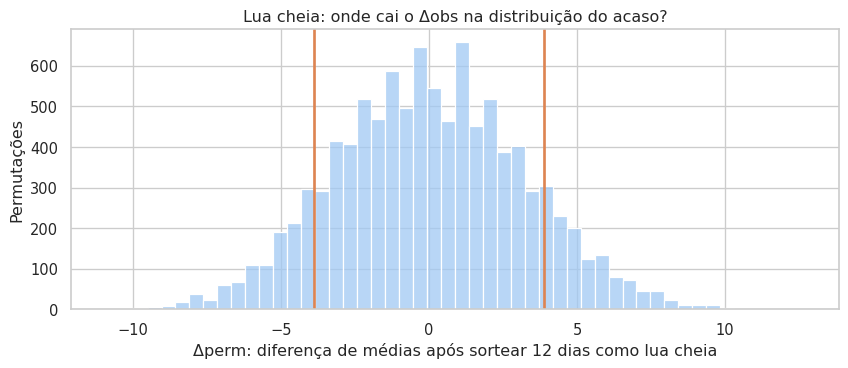

In [11]:
# Distribuição nula da lua cheia e posição do efeito observado
def plot_null(null, obs, title, xlabel):
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.histplot(null, bins=50, color="#A1C9F4", ax=ax)
    for value in [-obs, obs]:
        ax.axvline(value, color="#DD8452", linewidth=2)
    ax.set(title=title, xlabel=xlabel, ylabel="Permutações")
    plt.tight_layout()
    plt.show()

plot_null(
    moon_null,
    moon_obs,
    title="Lua cheia: onde cai o Δobs na distribuição do acaso?",
    xlabel="Δperm: diferença de médias após sortear 12 dias como lua cheia",
)

A distribuição nula tem duas características que valem para qualquer
teste de permutação de diferença de médias:

-   **Centro em zero.** Sob $H_0$, nenhum grupo é favorecido. Para cada
    sorteio que coloca os dias movimentados na lua cheia, há outro que
    os coloca nos demais dias.
-   **Largura que reflete a oscilação do acaso.** A maior parte das
    diferenças fica entre $-6$ e $+6$ atendimentos. Essa faixa é o que o
    acaso, sozinho, consegue produzir com 12 dias contra 353.

O efeito observado cai em uma região bem povoada da distribuição, longe
das caudas. A proporção de permutações com resultado tão ou mais extremo
que $\Delta_{obs}$ responde à pergunta “quão comum é esse resultado sob
o acaso?”:

In [12]:
# Proporção de permutações tão ou mais extremas que o observado
moon_p = np.mean(np.abs(moon_null) >= abs(moon_obs))

moon_p

np.float64(0.23)

> **Por que 10.000 permutações?**
>
> A proporção calculada é uma **estimativa** do *p*-valor exato, que
> exigiria percorrer todas as divisões possíveis. Como toda estimativa
> por sorteio, ela tem um erro. Com 10.000 permutações e um *p*-valor em
> torno de 0,2, esse erro é da ordem de 0,004, pequeno demais para mudar
> qualquer conclusão. Mais permutações tornam a estimativa mais precisa,
> ao custo de mais tempo de execução. A semente fixa em
> `permutation_null` garante que o resultado seja reproduzível.

## 4.3 O *p*-valor

Essa proporção tem nome. O ***p*-valor** é a probabilidade, **supondo
$H_0$ verdadeira**, de obter um efeito tão ou mais extremo que o
observado:

$$
p = P\left(|\Delta_{perm}| \geq |\Delta_{obs}| \;\middle|\; H_0 \text{ verdadeira}\right)
$$

Cada parte da definição tem um papel:

-   **“Supondo $H_0$ verdadeira”**: a probabilidade é calculada no mundo
    em que não há efeito. Por isso usamos a distribuição nula,
    construída com rótulos embaralhados.
-   **“Tão ou mais extremo”**: não perguntamos pela chance de obter
    exatamente 3,88, que é praticamente nula para qualquer valor
    específico. Perguntamos pela chance de obter algo pelo menos tão
    afastado de zero. Daí o sinal $\geq$.
-   **Valor absoluto**: como o teste é bilateral, diferenças de
    $-3{,}88$ ou menos também contam como tão extremas quanto $+3{,}88$.

No pronto-socorro, cerca de 23% das permutações produziram diferenças
pelo menos tão grandes quanto a observada. Uma diferença de 3,9
atendimentos é, portanto, um resultado corriqueiro quando a lua não tem
efeito algum. Aproximadamente um em cada quatro sorteios de 12 dias
produziria algo assim.

O *p*-valor é frequentemente mal interpretado. A American Statistical
Association publicou uma declaração específica sobre o tema (Wasserstein
& Lazar, 2016). A tabela a seguir resume os pontos principais com o
exemplo da lua cheia:

| O *p*-valor é | Na lua cheia |
|------------------------------------|------------------------------------|
| Uma probabilidade condicional a $H_0$ | **Se** a lua não tiver efeito, 23% dos sorteios produzem uma diferença tão grande quanto a observada |
| Uma medida de quão atípicos os dados são sob o acaso | Os dados são bastante típicos de um mundo sem efeito da lua |
| Dependente do tamanho da amostra | Com 10 anos de dados, a mesma diferença de 3,9 atendimentos teria um *p*-valor bem menor |

| O *p*-valor não é | Interpretação errada na lua cheia |
|------------------------------------|------------------------------------|
| A probabilidade de $H_0$ ser verdadeira | “Há 23% de chance de a lua não ter efeito” |
| A probabilidade de o resultado ser “mero acaso” | “Há 23% de chance de a diferença ser acaso” |
| Uma medida do tamanho ou da importância do efeito | “Um *p*-valor menor significaria um efeito maior da lua” |

> **Important**
>
> O *p*-valor responde a “**se** não houvesse efeito, quão raro seria
> este resultado?”. Ele não responde a “qual é a probabilidade de não
> haver efeito?”. As duas perguntas têm respostas diferentes.

## 4.4 A regra de decisão

O *p*-valor é um número contínuo, mas muitas vezes precisamos de uma
decisão: agir ou não agir, reforçar ou não a escala de plantão. Para
isso, fixamos **antes da análise** um limiar chamado **nível de
significância**, $\alpha$. O valor convencional é $\alpha = 0{,}05$.

| Resultado | Decisão | Leitura |
|------------------------|------------------------|------------------------|
| $p \leq \alpha$ | Rejeita-se $H_0$ | Os dados são atípicos demais para o acaso. O efeito é estatisticamente significante |
| $p > \alpha$ | Não se rejeita $H_0$ | A diferença é compatível com a flutuação aleatória. Isso não prova que $H_0$ seja verdadeira |

O valor de $\alpha$ tem uma interpretação direta. Se $H_0$ for
verdadeira, o *p*-valor ficará abaixo de 0,05 em 5% das vezes, apenas
por acaso. Ao usar $\alpha = 0{,}05$, aceitamos errar dessa forma em 5%
dos testes sem efeito real. A seção 6.2 ilustra essa propriedade com uma
simulação.

Na lua cheia, $p \approx 0{,}23 > 0{,}05$. Não rejeitamos $H_0$: o
“plantão de lua cheia” é compatível com o acaso. Neste caso, sabemos que
a decisão está correta, porque construímos os dados sem efeito.

> **Por que 0,05?**
>
> O valor é uma convenção, popularizada por R. A. Fisher na década de
> 1920, e não uma propriedade matemática. Áreas diferentes adotam
> limiares diferentes. A física de partículas, por exemplo, exige
> evidências muito mais fortes antes de anunciar uma descoberta. O
> importante é fixar $\alpha$ antes de olhar os dados. Escolher o limiar
> depois de ver o *p*-valor é uma versão da falácia do atirador do
> Texas.

## 4.5 Permutação no `mtcars`

Repetimos o procedimento para o câmbio. Sob $H_0$, o câmbio não afeta o
consumo, e os 32 valores de `mpg` vêm de uma única distribuição.
Qualquer divisão em 13 manuais e 19 automáticos seria tão plausível
quanto a real. Há cerca de 347 milhões dessas divisões, e novamente
sorteamos 10.000 delas.

In [13]:
# Distribuição nula do câmbio
mpg_values = mtcars["mpg"].to_numpy()
mpg_labels = (mtcars["am"] == 1).to_numpy()

mpg_null = permutation_null(mpg_values, mpg_labels)

mpg_p = np.mean(np.abs(mpg_null) >= abs(delta_obs))

mpg_p

np.float64(0.0001)

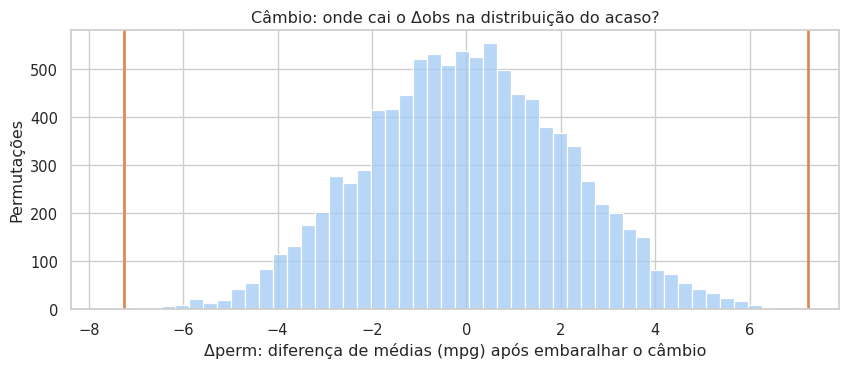

In [14]:
# Distribuição nula do câmbio e posição do efeito observado
plot_null(
    mpg_null,
    delta_obs,
    title="Câmbio: onde cai o Δobs na distribuição do acaso?",
    xlabel="Δperm: diferença de médias (mpg) após embaralhar o câmbio",
)

A distribuição nula tem a mesma forma de sino centrada em zero, agora na
escala de milhas por galão. A maior parte das diferenças produzidas pelo
acaso fica entre $-4$ e $+4$ mpg. As linhas do efeito observado ficam
nas extremidades, fora da região ocupada pelas permutações. Apenas uma
em 10.000 chegou a uma diferença de 7,24 mpg. Como $p < 0{,}05$,
rejeitamos $H_0$: uma diferença desse tamanho seria muito rara se o
câmbio não importasse.

> **Resolução do *p*-valor por permutação**
>
> Com 10.000 permutações, a menor proporção diferente de zero é
> $1/10.000 = 0{,}0001$. Um resultado de 0,0001 indica apenas que o
> *p*-valor é muito pequeno, e a forma honesta de reportá-lo é
> “$p < 0{,}001$”. Para distinguir *p*-valores ainda menores, seriam
> necessárias mais permutações.

> **Warning**
>
> Rejeitar $H_0$ indica que a diferença dificilmente é acaso. **Não**
> indica que o câmbio seja a causa da diferença. Os carros manuais da
> base também diferem dos automáticos em outras características, uma
> questão que retomaremos na Pergunta 2.

# 5. O atalho paramétrico

O teste de permutação constrói a distribuição nula por simulação. Um
teste **paramétrico** chega ao mesmo destino por outro caminho. O nome
vem de **parâmetro**: uma quantidade fixa que descreve uma população
inteira, como a média $\mu$ ou o desvio-padrão $\sigma$. Em vez de
simular, o teste paramétrico supõe que os dados seguem uma família de
distribuições conhecida e usa a teoria para deduzir a distribuição nula.
O procedimento tem três etapas:

1.  **Supor um modelo.** Os dados, ou as médias, seguem uma família
    conhecida, como a normal, com parâmetros $\mu$ e $\sigma$.
2.  **Derivar a distribuição nula.** Sob $H_0$, a estatística do teste
    segue uma distribuição teórica, como *t*, *F*, $\chi^2$ ou *Z*.
3.  **Ler o *p*-valor.** A área na cauda vem de uma fórmula, sem simular
    nada.

A vantagem é a rapidez e, quando as premissas valem, um poder maior. O
risco é que, se as premissas falharem, o *p*-valor pode enganar.

## 5.1 O erro-padrão

Para substituir a simulação, a teoria precisa saber **quanto a diferença
de médias oscila por acaso**. Essa oscilação corresponde à largura da
distribuição nula, que podemos medir pelo desvio-padrão das permutações:

In [15]:
# Largura da distribuição nula do câmbio, medida pela simulação
round(mpg_null.std(), 2)

np.float64(2.16)

A teoria prevê essa largura sem simular nada. O raciocínio tem duas
etapas:

1.  **A média de um grupo oscila menos que os dados individuais.** Se os
    dados têm desvio-padrão $s$, a média de $n$ observações
    independentes tem variância $s^2/n$. Quanto maior o grupo, mais
    estável é sua média.
2.  **A variância de uma diferença soma as variâncias.** Quando
    subtraímos duas médias independentes, as oscilações das duas se
    acumulam. A variância de $\bar{x}_A - \bar{x}_B$ é
    $s^2/n_A + s^2/n_B$.

Sob $H_0$, os dois grupos vêm da mesma população, cujo desvio-padrão
estimamos com os 32 carros juntos. Tirando a raiz quadrada da variância,
chegamos à largura da distribuição nula:

$$
SE = \sqrt{\frac{s^2}{n_A} + \frac{s^2}{n_B}} = s \sqrt{\frac{1}{n_A} + \frac{1}{n_B}}
$$

In [16]:
# Largura da distribuição nula do câmbio, prevista pela fórmula
n_manual, n_automatic = len(manual), len(automatic)

se_null = mtcars.mpg.std() * np.sqrt(1 / n_manual + 1 / n_automatic)

round(se_null, 2)

np.float64(2.17)

Os dois valores praticamente coincidem: 2,16 mpg pela simulação e 2,17
mpg pela fórmula. A curva normal com essa largura descreve bem o
histograma das permutações:

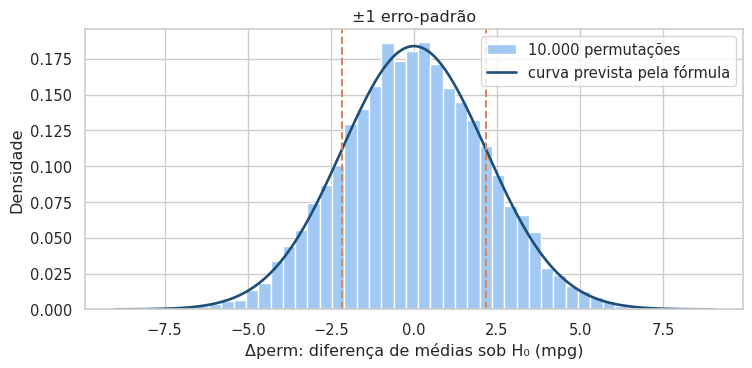

In [17]:
# Histograma das permutações e curva normal prevista pela fórmula
fig, ax = plt.subplots(figsize=(8, 4))

grid = np.linspace(-9, 9, 300)

ax.hist(mpg_null, bins=40, density=True,
        color="#A1C9F4", label="10.000 permutações")
ax.plot(grid, stats.norm.pdf(grid, 0, se_null),
        color="#1F4E79", linewidth=2, label="curva prevista pela fórmula")
        
for value in [-se_null, se_null]:
    ax.axvline(value, color="#DD8452", linestyle="--")

ax.set(title="±1 erro-padrão", xlabel="Δperm: diferença de médias sob H₀ (mpg)",
       ylabel="Densidade")
ax.legend()

plt.tight_layout()
plt.show()

Essa largura recebe o nome de **erro-padrão** (SE, do inglês *standard
error*). Ela funciona como a régua do acaso: as linhas tracejadas marcam
um erro-padrão para cada lado de zero, e cerca de dois terços das
permutações caem entre elas.

## 5.2 Desvio-padrão e erro-padrão

Os dois termos se parecem, mas medem coisas diferentes:

|  | Desvio-padrão ($s$) | Erro-padrão ($SE$) |
|------------------------|------------------------|------------------------|
| O que mede | A dispersão dos **dados individuais** em torno da média | A variabilidade da **própria estimativa**, como $\bar{x}$, entre amostras repetidas |
| Com mais dados | Não diminui: é uma característica da população | Diminui: $SE(\bar{x}) = s / \sqrt{n}$ |

O pronto-socorro simulado ilustra a diferença. Sorteamos 2.000 amostras
de cada tamanho a partir dos 365 dias e, para cada tamanho, calculamos
duas coisas: o desvio-padrão típico **dentro** de uma amostra e o
desvio-padrão das médias **entre** as amostras.

In [18]:
# Desvio-padrão dos dados e das médias amostrais, por tamanho de amostra
rng = np.random.default_rng(42)

def sample_summary(n, n_samples=2_000):
    samples = rng.choice(moon_values, size=(n_samples, n))
    return {
        "dp_dos_dados": samples.std(axis=1, ddof=1).mean(),
        "dp_das_medias": samples.mean(axis=1).std(ddof=1),
        "previsto_s_raiz_n": moon_values.std(ddof=1) / np.sqrt(n),
    }

(
    pd.DataFrame({n: sample_summary(n) for n in [10, 40, 160, 640]})
    .T
    .rename_axis("n")
    .round(2)
)

Cada coluna da tabela responde a uma pergunta:

-   **`dp_dos_dados`**: quanto variam os dias dentro de uma amostra?
    Cerca de 11 atendimentos, qualquer que seja $n$. Coletar mais dias
    não torna cada dia menos variável.
-   **`dp_das_medias`**: quanto varia a média de uma amostra para outra?
    Com 10 dias, cerca de 3,5 atendimentos. Com 640 dias, cerca de 0,4.
    Cada vez que $n$ quadruplica, esse valor cai pela metade.
-   **`previsto_s_raiz_n`**: o que a fórmula $s/\sqrt{n}$ prevê? Valores
    muito próximos da coluna anterior, o que confirma a fórmula.

Em resumo, o desvio-padrão descreve os **dados**, e o erro-padrão
descreve a **precisão da estimativa**. O erro-padrão diz o quanto a
estimativa mudaria se a coleta fosse repetida com outra amostra do mesmo
tamanho.

## 5.3 A estatística *t*

Com a régua definida, a pergunta se torna: **quantos erros-padrão cabem
entre 0 e $\Delta_{obs}$?**

In [19]:
# Efeito observado do câmbio, medido em erros-padrão
round(delta_obs / se_null, 2)

np.float64(3.34)

Cabem cerca de 3,3 erros-padrão. Sob o acaso, a diferença de médias
quase nunca ultrapassa 2 erros-padrão: na curva normal, cerca de 95% da
área fica entre $-2$ e $+2$. Essa contagem é a **estatística *t***:

$$
t = \frac{\bar{x}_A - \bar{x}_B}{SE}
$$

A vantagem de medir a diferença em erros-padrão é que o resultado deixa
de depender da unidade. Uma diferença de 7 mpg e uma de 4 atendimentos
não são comparáveis diretamente. Medidas em erros-padrão, as duas passam
a estar na mesma régua.

A fórmula da seção 5.1 usou um único desvio-padrão para os dois grupos.
A versão de **Welch** estima a variância de cada grupo separadamente e
não exige que sejam iguais:

$$
SE = \sqrt{\frac{s_A^2}{n_A} + \frac{s_B^2}{n_B}}
$$

Aqui, $s_A^2$ e $s_B^2$ são as variâncias amostrais e $n_A$ e $n_B$, os
tamanhos dos grupos.

In [20]:
# Estatística t de Welch calculada pela fórmula
se_welch = np.sqrt(manual.var() / n_manual + automatic.var() / n_automatic)

round(se_welch, 2), round(delta_obs / se_welch, 2)

(np.float64(1.92), np.float64(3.77))

O erro-padrão de Welch (1,92 mpg) é menor que o da seção 5.1 (2,17 mpg),
e o *t* sobe de 3,34 para 3,77. A diferença tem uma explicação. O
desvio-padrão dos 32 carros juntos inclui a distância entre os dois
grupos: misturar manuais econômicos com automáticos menos econômicos
aumenta a dispersão total. A versão de Welch mede a variação **dentro**
de cada grupo e não é inflada por essa distância.

O teste *t* converte o número de erros-padrão em uma probabilidade. Para
isso, usa a distribuição *t* em vez da normal. As duas têm forma de
sino, mas a *t* tem caudas mais pesadas. A razão é que o erro-padrão
também é estimado a partir dos dados e, em amostras pequenas, essa
estimativa pode errar. A distribuição *t* incorpora essa incerteza extra
por meio dos **graus de liberdade** (*df*, do inglês *degrees of
freedom*), que crescem com o tamanho das amostras. Com poucos graus de
liberdade, as caudas são pesadas. Com muitos, a distribuição *t* se
aproxima da normal.

**O que são graus de liberdade?** Pense em três números cuja média
precisa ser 10. Você pode escolher os dois primeiros à vontade, por
exemplo 8 e 15. O terceiro, porém, já está decidido: tem de ser 7. São
três números, mas só dois são livres. Esse é o número de graus de
liberdade.

O desvio-padrão sofre a mesma restrição, porque é calculado em torno da
média da própria amostra. Por isso, uma amostra de $n$ observações tem
$n - 1$ graus de liberdade. Com dois grupos, cada um perde um, e sobram
$n_A + n_B - 2$: no `mtcars`, $13 + 19 - 2 = 30$. A versão de Welch
ajusta esse número conforme a variância de cada grupo e chega a cerca de
18,3.

Na prática, os graus de liberdade dizem **quanta informação** temos para
estimar a variabilidade. Com pouca informação, a curva *t* é mais
cautelosa e exige uma diferença maior para rejeitar $H_0$:

| Graus de liberdade    | Erros-padrão necessários para $p \leq 0{,}05$ |
|-----------------------|-----------------------------------------------|
| 2                     | 4,30                                          |
| 5                     | 2,57                                          |
| 30                    | 2,04                                          |
| Muitos (curva normal) | 1,96                                          |

A partir de algumas dezenas de graus de liberdade, o limite fica perto
de 2. Daí a regra prática de que, sob o acaso, a estatística quase nunca
ultrapassa 2 erros-padrão.

Na prática, `stats.ttest_ind` faz todo o cálculo. Guardamos o resultado
em uma variável para reaproveitá-lo na seção 5.6:

In [21]:
# Teste t de Welch no mtcars
mpg_ttest = stats.ttest_ind(manual, automatic, equal_var=False)

mpg_ttest

TtestResult(statistic=np.float64(3.767123145144923), pvalue=np.float64(0.0013736383330710345), df=np.float64(18.332251638400464))

O resultado tem três campos:

-   **`statistic`**: a estatística *t*, 3,77, a mesma calculada pela
    fórmula.
-   **`pvalue`**: o *p*-valor bilateral, 0,0014.
-   **`df`**: os graus de liberdade estimados pela fórmula de Welch,
    cerca de 18,3. O valor não é inteiro porque Welch ajusta os graus de
    liberdade conforme as variâncias e os tamanhos dos grupos.

E no pronto-socorro:

In [22]:
# Teste t de Welch na lua cheia
moon_ttest = stats.ttest_ind(moon_in, moon_out, equal_var=False)

moon_ttest

TtestResult(statistic=np.float64(1.4048153658505091), pvalue=np.float64(0.1853402601391711), df=np.float64(12.043510826046889))

Aqui, $t \approx 1{,}40$. A diferença observada cabe menos de uma vez e
meia na régua do acaso, bem abaixo do limiar aproximado de 2
erros-padrão. O *p*-valor, cerca de 0,19, confirma que o resultado é
comum sob $H_0$.

As conclusões coincidem com as da permutação. No `mtcars`, $p < 0{,}05$
e rejeitamos $H_0$. Na lua cheia, $p > 0{,}05$ e não rejeitamos.

> **Por que “Student”?**
>
> William S. Gosset era químico da cervejaria Guinness e precisava tirar
> conclusões de amostras pequenas de cevada. A cervejaria não permitia
> que seus funcionários publicassem com o próprio nome, e Gosset
> publicou o teste em 1908 sob o pseudônimo “Student”.

## 5.4 Premissas e limitações do teste *t*

O atalho paramétrico só é confiável quando suas premissas são razoáveis.
A tabela relaciona cada premissa ao modo de verificá-la e ao que
acontece quando ela falha:

| Premissa | Como verificar | Quando falha |
|------------------------|------------------------|------------------------|
| Observações independentes | Examinar como os dados foram coletados: medições repetidas no mesmo indivíduo ou dias consecutivos podem estar relacionados | Dados pareados ou temporais exigem outra versão do teste |
| Médias aproximadamente normais | Histograma ou boxplot de cada grupo. Pelo teorema central do limite, a premissa é mais tranquila com *n* moderado ou grande | Amostras pequenas e muito assimétricas distorcem o *p*-valor |
| Variável em escala contínua | Verificar o tipo da variável | Variáveis ordinais ou categóricas pedem outros testes |
| Na versão de Welch, as variâncias podem ser diferentes | Comparar os desvios-padrão dos grupos | A versão clássica, com `equal_var=True`, perde a validade quando as variâncias diferem muito |

Há ainda duas limitações que não dependem de premissas. O teste *t*
compara **médias**, e não medianas ou formas de distribuição. E, por
depender de média e variância, ele é sensível a valores atípicos.

## 5.5 Um único valor atípico muda a história

Na Aula 5, vimos que média e desvio-padrão são sensíveis a valores
extremos. O teste *t* depende das duas medidas e herda essa fragilidade.
Para ver o efeito, acrescentamos um carro automático cujo consumo foi
digitado como 60 mpg, um erro de registro plausível.

In [23]:
# Automáticos com um consumo digitado como 60 mpg
automatic_typo = pd.concat(
    [automatic, pd.Series([60.])],
    ignore_index=True,
)

A função abaixo reúne, para dois grupos, as medidas que o valor atípico
pode afetar. Aplicamos a função à base original e à base com o valor
digitado errado:

In [24]:
# Diferenças, dispersão e teste t, sem e com o valor digitado errado
def compare(group_a, group_b):
    test = stats.ttest_ind(group_a, group_b, equal_var=False)
    return {
        "dif_medias": group_a.mean() - group_b.mean(),
        "dif_medianas": group_a.median() - group_b.median(),
        "dp_automaticos": group_b.std(),
        "t": test.statistic,
        "p": test.pvalue,
    }

In [25]:
(
    pd.DataFrame(
        {
            "mtcars original": compare(manual, automatic),
            "+1 automático com 60 mpg": compare(manual, automatic_typo),
        }
    )
    .T
    .round(4)
)

Um único valor errado age sobre as duas partes da estatística *t* ao
mesmo tempo:

1.  **O numerador diminui.** O carro de 60 mpg eleva a média dos
    automáticos, e a diferença de médias cai de 7,24 para 5,10 mpg.
2.  **O denominador aumenta.** O desvio-padrão dos automáticos quase
    triplica, de 3,83 para 10,28 mpg. Com ele, cresce o erro-padrão.
3.  **A razão despenca.** Com o numerador menor e o denominador maior,
    *t* cai de 3,77 para 1,78, e o *p*-valor sobe de 0,0014 para 0,085.

O teste **deixa de detectar** a diferença ao nível de 5%. A diferença de
medianas, por outro lado, quase não se altera (de 5,50 para 5,25 mpg),
porque a mediana depende apenas da ordenação dos valores.

> **Important**
>
> Diagnostique com boxplots **antes** de testar. Diante de valores
> atípicos, considere corrigir valores sentinela ou erros de registro,
> aplicar uma transformação como $\log(x)$, vista na Aula 6, ou usar uma
> permutação sobre a diferença de medianas.

## 5.6 Permutação e teste *t*

Os dois métodos respondem à mesma pergunta por caminhos diferentes:

| Dimensão | Permutação (não paramétrico) | Teste *t* (paramétrico) |
|------------------------|------------------------|------------------------|
| Premissas | Livre de distribuição. Exige apenas intercambialidade sob $H_0$ | Médias aproximadamente normais. Escala contínua |
| Custo computacional | Milhares de reamostragens | Irrisório: fórmula fechada |
| Tamanho dos dados | Bom para amostras pequenas e dados assimétricos | Adequado para volumes moderados e grandes |
| Interpretação | Frequência empírica do reordenamento aleatório | Posição de *t* em uma distribuição teórica |
| Flexibilidade | Qualquer estatística: média, mediana, razão | Diferença de médias |

In [26]:
# p-valores dos dois métodos nos dois exemplos
(
    pd.DataFrame(
        {
            "permutação": [mpg_p, moon_p],
            "teste t (Welch)": [mpg_ttest.pvalue, moon_ttest.pvalue],
        },
        index=["mtcars", "Lua cheia"],
    )
    .round(4)
)

Os valores não são idênticos, porque os dois métodos constroem a
distribuição nula de formas diferentes. No `mtcars`, o teste *t* dá
0,0014 e a permutação, 0,0001. Duas razões explicam a distância. Com
cerca de 18 graus de liberdade, a distribuição *t* tem caudas mais
pesadas que a distribuição das permutações e atribui mais probabilidade
a valores extremos. Além disso, o *p*-valor da permutação está no limite
da sua resolução. Na lua cheia, os valores ficam próximos (0,23 e 0,19).
As decisões, porém, coincidem nos dois exemplos.

# 6. Armadilhas da decisão

Um teste de hipóteses termina em uma decisão, e toda decisão tomada com
dados incompletos pode errar. Esta seção trata de três armadilhas: os
dois tipos de erro, a multiplicação de testes e a confusão entre
significância estatística e relevância prática.

## 6.1 Dois tipos de erro

Como nunca sabemos se $H_0$ é verdadeira, há quatro combinações
possíveis entre a realidade e a decisão:

|  | $H_0$ verdadeira | $H_0$ falsa |
|------------------------|------------------------|------------------------|
| **Rejeitar $H_0$** | Erro do tipo I ($\alpha$): falso positivo, “descobrir” um efeito que não existe | Decisão correta: poder estatístico ($1 - \beta$) |
| **Não rejeitar $H_0$** | Decisão correta: confiança ($1 - \alpha$) | Erro do tipo II ($\beta$): falso negativo, não detectar um efeito real |

Os dois erros têm consequências concretas nos exemplos da aula. No
`mtcars`, os erros seriam: a) do tipo I, concluir que o câmbio manual
economiza combustível quando a diferença era acaso; b) do tipo II,
deixar passar um efeito pequeno, mas real, do câmbio, já que a amostra
tem só 32 carros. Na lua cheia, seriam: a) do tipo I, reforçar a escala
de plantão em toda lua cheia sem necessidade; b) do tipo II, não
perceber um efeito pequeno da lua, caso ele existisse, porque 12 noites
por ano são poucas para detectá-lo.

O nível de significância $\alpha$ é exatamente a taxa de erro do tipo I
que aceitamos. Ao usar $\alpha = 0{,}05$, admitimos que, entre os testes
feitos sem efeito real, cerca de 5% levarão a uma rejeição apenas por
acaso. O limiar define, por construção, a taxa de alarmes falsos.

O erro do tipo II depende de fatores que $\alpha$ não controla. O
**poder** de um teste, $1 - \beta$, é a probabilidade de rejeitar $H_0$
quando existe um efeito real, ou seja, de detectar o que de fato existe.
Ele cresce com o tamanho do efeito e com a quantidade de dados. Efeitos
grandes se destacam facilmente da oscilação do acaso. Efeitos pequenos
só aparecem quando há observações suficientes para estreitar a
distribuição nula. É por isso que um ano de dados, com apenas 12 noites
de lua cheia, dificilmente detectaria um efeito pequeno da lua, mesmo
que ele existisse.

Os dois erros estão em tensão. Reduzir $\alpha$ torna o critério mais
exigente e diminui os falsos positivos, mas também dificulta a detecção
de efeitos reais e aumenta $\beta$. Para um $\alpha$ fixo, a forma de
reduzir $\beta$ é **aumentar $n$**: com mais dados, o erro-padrão
diminui, e o efeito se separa melhor do acaso.

## 6.2 Muitos testes

O nível $\alpha$ controla o erro de **um** teste. Quando fazemos muitos
testes, os falsos positivos se acumulam. Imagine 20 pronto-socorros em
que a lua não tem efeito, cada um testado com $\alpha = 0{,}05$:

In [27]:
# p-valores da lua cheia em 20 pronto-socorros sem efeito
rng = np.random.default_rng(7)

hospital_p = stats.ttest_ind(
    rng.poisson(120, size=(20, 12)),
    rng.poisson(120, size=(20, 353)),
    axis=1,
    equal_var=False,
).pvalue

O gráfico mostra o *p*-valor de cada pronto-socorro e o limiar
$\alpha = 0{,}05$:

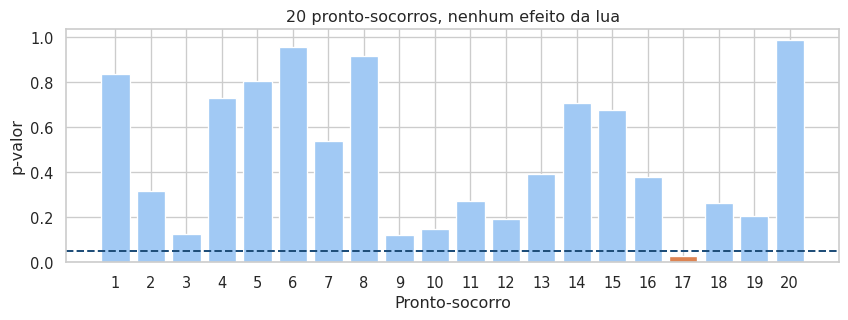

In [28]:
# p-valor de cada pronto-socorro, com destaque para as rejeições
fig, ax = plt.subplots(figsize=(9, 3.5))

ax.bar(
    np.arange(1, 21),
    hospital_p,
    color=np.where(hospital_p <= .05, "#DD8452", "#A1C9F4"),
)
ax.axhline(.05, color="#1F4E79", linestyle="--")
ax.set(
    title="20 pronto-socorros, nenhum efeito da lua",
    xlabel="Pronto-socorro",
    ylabel="p-valor",
    xticks=np.arange(1, 21),
)

plt.tight_layout()
plt.show()

A barra laranja marca o único pronto-socorro em que o teste rejeitou
$H_0$, apenas por acaso. Um em 20 é exatamente o que $\alpha = 0{,}05$
prevê. Note que, sob $H_0$, os *p*-valores se espalham por todo o
intervalo entre 0 e 1. Valores pequenos aparecem de vez em quando, mesmo
sem efeito algum.

A probabilidade de **pelo menos um** falso positivo em $k$ testes
independentes sem efeito é o complemento da probabilidade de nenhum
deles errar:

$$
P(\text{pelo menos um falso positivo}) = 1 - (1 - \alpha)^k
$$

Com 20 testes, $1 - 0{,}95^{20} \approx 64\%$. Uma solução simples é a
**correção de Bonferroni**: usar $\alpha/k$ como limiar em cada teste. A
tabela compara as duas abordagens:

In [29]:
# Probabilidade de pelo menos um falso positivo em k testes sem efeito
alpha = .05

(
    pd.DataFrame({"k": [1, 5, 20, 100]})
    .assign(
        sem_correcao=lambda df: 1 - (1 - alpha) ** df["k"],
        bonferroni=lambda df: 1 - (1 - alpha / df["k"]) ** df["k"],
    )
    .set_index("k")
    .round(3)
)

Sem correção, a chance de pelo menos um alarme falso cresce rapidamente
e chega a quase 100% com 100 testes. Com Bonferroni, ela fica em torno
de 5%, qualquer que seja $k$. O custo é um critério mais exigente para
cada teste e, portanto, menos poder.

O problema não se restringe a vários hospitais. Ele aparece sempre que
um analista testa muitas variáveis, muitos subgrupos ou muitas versões
da mesma análise e relata apenas os resultados significantes. Essa
prática, conhecida como *p-hacking*, é a falácia do atirador do Texas
aplicada a testes de hipóteses: os tiros são os testes, e o alvo é
desenhado em volta dos que deram $p < 0{,}05$.

## 6.3 Significância estatística não é relevância prática

O *p*-valor depende do tamanho da amostra. Isso decorre da própria
estatística *t*. Para dois grupos de tamanho $n$ e um efeito de $d$
desvios-padrão, a estatística vale aproximadamente:

$$
t = d \sqrt{\frac{n}{2}}
$$

O efeito $d$ fica fixo, mas $\sqrt{n}$ cresce sem limite. Mesmo um
efeito minúsculo acaba gerando um *t* grande quando $n$ é grande o
bastante. A tabela mostra o *p*-valor de um mesmo efeito minúsculo, de
0,02 desvio-padrão, para tamanhos de amostra crescentes:

In [30]:
# p-valor de um efeito fixo de 0,02 desvio-padrão, por tamanho de grupo
(
    pd.Series(
        {
            n: 2 * stats.t.sf(.02 * np.sqrt(n / 2), df=2 * n - 2)
            for n in [100, 1_000, 10_000, 100_000, 1_000_000]
        },
        name="p",
    )
    .rename_axis("n por grupo")
    .to_frame()
)

Com 100 ou 1.000 observações por grupo, o efeito é indistinguível do
acaso. Com 100.000, o *p*-valor já é da ordem de $10^{-6}$. Com um
milhão, ele chega a cerca de $10^{-45}$. O efeito não mudou em nenhuma
linha da tabela: o que mudou foi apenas a capacidade de detectá-lo. Em
grandes bases de dados, quase tudo se torna “significante”.

Por isso, além do *p*-valor, reporte o **tamanho do efeito**. Uma medida
comum é o *d* de Cohen, a diferença de médias expressa em
desvios-padrão:

$$
d = \frac{\bar{x}_A - \bar{x}_B}{s_{\text{combinado}}}
$$

Aqui, $s_{\text{combinado}}$ é um desvio-padrão comum aos dois grupos,
obtido a partir de uma média das variâncias de cada grupo, ponderada
pelos seus tamanhos. Assim como a estatística *t*, o *d* mede a
diferença em uma régua sem unidade. A diferença está na régua escolhida.
O *t* divide pelo erro-padrão, que encolhe com $\sqrt{n}$. O *d* divide
pelo desvio-padrão dos dados, que não depende de $n$. Por isso, o *d*
não cresce com o tamanho da amostra: ele mede o quanto os grupos estão
separados em relação à variação típica dos dados.

Como referência, valores de *d* em torno de 0,2, 0,5 e 0,8 costumam ser
descritos como efeitos pequenos, médios e grandes. No `mtcars`,
$d \approx 1{,}48$: as médias estão separadas por cerca de um
desvio-padrão e meio, um efeito grande. O tamanho do efeito descreve a
magnitude da diferença na amostra. O *p*-valor, por sua vez, informa se
essa diferença se distingue do acaso. As duas informações se
complementam, e nenhuma substitui a outra.

A pergunta final é se a diferença é **acionável**: grande o bastante e
bem compreendida o bastante para orientar uma decisão. Uma economia de 7
milhas por galão representa cerca de 40% a mais de distância com o mesmo
combustível, o que seria relevante para um comprador em 1974, logo após
a crise do petróleo. Mas, como discute a Pergunta 2, saber que a
diferença existe ainda não diz o que a causa.

# 7. Guia rápido

A sequência abaixo responde à pergunta norteadora da aula.

| Passo | Ação | Ferramenta |
|------------------------|------------------------|------------------------|
| 1\. Medir | Calcular $\Delta_{obs}$ e inspecionar os grupos | `groupby`, boxplot |
| 2\. Duvidar | Formular $H_0$: só há acaso | Hipóteses nula e alternativa |
| 3\. Simular | Construir a distribuição nula | Permutação ou distribuição *t* |
| 4\. Calcular | Obter o *p*-valor | `np.mean(np.abs(null) >= abs(obs))` ou `stats.ttest_ind` |
| 5\. Decidir | Comparar *p* com $\alpha$, corrigir para múltiplos testes, avaliar o tamanho do efeito e o contexto dos dados | Bonferroni, *d* de Cohen, contexto |

## Síntese

1.  **Efeito observado.** $\Delta_{obs}$ descreve a amostra. Sozinho,
    não prova um efeito populacional, porque a variabilidade amostral
    gera diferenças mesmo sem efeito real.
2.  **Hipótese nula.** $H_0$ formaliza o acaso. Sob ela, os rótulos dos
    grupos são intercambiáveis.
3.  **Distribuição nula.** A permutação, por simulação, e o teste *t*,
    por fórmula, constroem a distribuição da estatística sob $H_0$. O
    erro-padrão é a largura dessa distribuição.
4.  **Decisão.** $p \leq \alpha$ leva à rejeição de $H_0$. Com muitos
    testes, o limiar precisa ser corrigido. Tamanho do efeito, valores
    atípicos e o contexto dos dados decidem o que concluir.

Um efeito é “real” quando seria improvável sob o acaso. E só importa se
for grande e não for explicado por outra variável.

## Glossário

| Termo | Definição |
|------------------------------------|------------------------------------|
| $\Delta_{obs}$ | Diferença entre as estatísticas, como as médias, dos grupos na amostra |
| Erro-padrão (SE) | Variabilidade de uma estimativa entre amostras repetidas |
| Hipótese nula ($H_0$) | Modelo cético: não há efeito, e a diferença é fruto do acaso |
| Distribuição nula | Valores que a estatística assume quando $H_0$ é verdadeira |
| *p*-valor | Probabilidade de um resultado tão ou mais extremo que o observado, supondo $H_0$ |
| Significância ($\alpha$) | Limiar fixado antes da análise. Risco aceito de falso positivo |
| Poder ($1 - \beta$) | Probabilidade de detectar um efeito que de fato existe |
| Correção de Bonferroni | Uso de $\alpha/k$ como limiar em cada um de $k$ testes, para controlar a chance de algum falso positivo |
| *d* de Cohen | Diferença de médias expressa em desvios-padrão. Mede o tamanho do efeito |
| Confundidor | Variável que afeta o grupo e o desfecho, criando associação sem causa |

# Perguntas para consolidar

**Pergunta 1: o que o *p*-valor da lua cheia diz, e o que não diz?**

Na lua cheia, $p \approx 0{,}23$. Um colega conclui: “há 23% de chance
de a lua não ter efeito”. A frase está correta?

> **Como pensar sobre isso**
>
> Não. O *p*-valor é calculado **supondo** que $H_0$ seja verdadeira.
> Ele diz que, se a lua não tivesse efeito, cerca de 23% dos sorteios de
> 12 dias produziriam uma diferença pelo menos tão grande quanto a
> observada. Ele não atribui uma probabilidade à própria $H_0$.
>
> Também não podemos concluir que a lua não tem efeito. Não rejeitar
> $H_0$ significa apenas que os dados são compatíveis com o acaso. Como
> discutido na seção 6.1, com apenas 12 noites por ano o teste tem pouco
> poder, e mesmo um efeito real, mas pequeno, poderia passar
> despercebido.

**Pergunta 2: significativo quer dizer correto?**

No `mtcars`, a permutação deu $p < 0{,}001$. Isso significa que trocar o
câmbio de um carro faria ele economizar combustível?

> **Como pensar sobre isso**
>
> Não. O teste mostra que a diferença entre os grupos dificilmente é
> acaso, mas não identifica sua causa. Os manuais da amostra são, em sua
> maioria, compactos importados, enquanto os automáticos são, em grande
> parte, sedãs grandes e pesados. Carros mais leves consomem menos,
> qualquer que seja o câmbio. O peso, a potência e o número de cilindros
> também separam os grupos. Uma variável que afeta tanto o grupo quanto
> o desfecho, criando uma associação sem relação causal direta, é
> chamada de **confundidor**.
>
> Para atribuir um efeito causal, seria necessário comparar carros
> semelhantes em tudo, exceto no câmbio. Um experimento controlado faria
> isso por construção. Com dados observacionais, só podemos ajustar
> pelos confundidores que medimos.

**Pergunta 3: quando permutação e teste *t* discordam?**

Nos dois exemplos, os métodos levaram à mesma decisão. Em que situação
você esperaria que eles discordassem, e em qual confiaria mais?

> **Como pensar sobre isso**
>
> O teste *t* supõe que a diferença de médias seja aproximadamente
> normal. Isso é razoável com amostras moderadas ou grandes, pelo
> teorema central do limite. Com amostras pequenas e distribuições muito
> assimétricas ou com valores atípicos, a aproximação pode falhar, e o
> *p*-valor do teste *t* fica impreciso.
>
> A permutação exige apenas que os rótulos sejam intercambiáveis sob
> $H_0$. Ela continua válida nesses casos e ainda permite trocar a
> estatística, por exemplo pela diferença de medianas. Em contrapartida,
> ambos os métodos supõem observações independentes. Nenhum dos dois é
> adequado, sem adaptação, para dados pareados ou séries temporais.

# Para casa

1.  Adapte `permutation_null` para usar a diferença de **medianas**.
    Aplique-a ao cenário com o automático de 60 mpg e compare o
    *p*-valor com o do teste *t* da seção 5.5.
2.  Na base de imóveis da Aula 6, compare o aluguel de imóveis
    mobiliados e não mobiliados. Calcule $\Delta_{obs}$ e o *p*-valor
    por permutação e pelo teste *t*. Repita a análise com o $\log$ do
    aluguel e discuta as diferenças.
3.  Ainda na base de imóveis, a diferença de aluguel entre mobiliados e
    não mobiliados poderia ser explicada por outra variável? Proponha um
    confundidor e verifique sua hipótese com um gráfico.
4.  Antes de considerar o notebook pronto, use Restart Kernel and Run
    All.

## Referências

1.  Adhikari, A.; DeNero, J.; Wagner, D. *Computational and Inferential
    Thinking: The Foundations of Data Science*. 2. ed. UC Berkeley.
    [inferentialthinking.com](https://inferentialthinking.com)
2.  Bruce, P.; Bruce, A.; Gedeck, P. *Practical Statistics for Data
    Scientists*. 2. ed. O’Reilly, 2020.
3.  Student. The probable error of a mean. *Biometrika*, 6(1), 1-25,
    1908.
4.  Welch, B. L. The generalization of “Student’s” problem when several
    different population variances are involved. *Biometrika*, 34(1-2),
    28-35, 1947.
5.  Wasserstein, R. L.; Lazar, N. A. The ASA statement on p-values:
    context, process, and purpose. *The American Statistician*, 70(2),
    129-133, 2016.
6.  Fisher, R. A. *The Design of Experiments*. Edinburgh: Oliver & Boyd,
    1935.
7.  Rotton, J.; Kelly, I. W. Much ado about the full moon: a
    meta-analysis of lunar-lunacy research. *Psychological Bulletin*,
    97(2), 286-306, 1985.
8.  Henderson, H. V.; Velleman, P. F. Building multiple regression
    models interactively. *Biometrics*, 37(2), 391-411, 1981.

> Pode-se dizer que todo experimento existe apenas para dar aos fatos a
> chance de refutar a hipótese nula. (R. A. Fisher, *The Design of
> Experiments*, 1935, tradução livre)